In [ ]:
 #defines function to convert .idx files to .csv files
def IndexToCSV(file,output=None, model=None, fps=10,video=1, unique_adj=False):
    """
    A function to convert the whole index file (excluding the header) to a csv

    Parameters
    ----------
    file : Str
        Input .idx file location
    output : Str
        Output .csv file location  
    model : pkl model
        The model used to create the state classifier. If not supplied,
        the basic thresholding will be used (1mm/sec=locomotive, <1mm/sec = Stationary,
        >10px Activity Level = Stationary Active, <10px Activity Level = Stationary Static)
    fps : int (default 10).
        The fps of the recording.
    video : int (0 or 1)
        To say if you had created movr files when doing the experiment. 
        Default is yes (1). If you hadnt, use (0)
    Returns
    -------
    CSV if no output supplied.
    
    Outputs
    -------
    CSV
    """
    
    import struct
    import pandas as pd
    import joblib
    
    
    input_file_name = (file)
    input_file = open(input_file_name, 'rb')

    input_file.read(1)
    data1=input_file.read(4)
    metrics_list_array_size=struct.unpack(">I", data1)
    input_file.read(2*metrics_list_array_size[0])
    data3=input_file.read(4)
    record_size=struct.unpack(">i",data3)

    if video==1:    
        xx=0  
        while (byte := input_file.read(1)): 
            xx=xx+1#The while is to skip past the next few bytes until it finds the .movr bytes
            if b'.' in byte:
                byte = input_file.read(4)
                xx=xx+4
                if byte==b'movr':
                    break
                else:
                    continue
            else:
                continue
    elif video==0:
        xx=0  
        while (byte := input_file.read(1)): 
            xx=xx+1#The while is to skip past the next few bytes until it finds the .movr bytes
            if b'V' in byte:
                byte = input_file.read(3)
                xx=xx+3
                if byte==b'OID':
                    break
                else:
                    continue
            else:
                continue
    input_file.read(8)
    input_file.read(8)
    data5=input_file.read(4)
    group_string_length = struct.unpack(">I", data5)

    input_file.read(group_string_length[0])
    if group_string_length[0] > 0:
        group_string=struct.unpack(">c", data5)
        print(group_string)
    data7=input_file.read(48)


    #reading bytes?
    import os
    size = os.path.getsize(input_file_name)
    s = size -(77+(2*metrics_list_array_size[0])+(group_string_length[0])+xx)   #Not sure if the xx will work for all cases.. in this case is 69
    record_length = s/record_size[0]

    cols = ['Record Number', 'Timestamp (ms)', 'State', 'Activity Level', 'Movr Frame', 'cXmm', 'Speed_Av_mm_per_sec', 'Heading_deg', 'cYmm', 'Error_code'] #Will need to change the metric names if they change
    lst = []
    
    from tqdm import tqdm
    for n in tqdm(range(0,int(record_length))):
        data7=input_file.read(4)
        ms_time=struct.unpack(">I", data7)

        data8=input_file.read(1)
        state=struct.unpack(">B",data8)
        if state[0] == 0:
            x="Unknown"
        elif state[0] == 1:
            x="Locomotive"
        elif state[0] == 2:
            x="Stationary"
        elif state[0]== 3:
            x="Stationary Static"
        elif state[0]==4:
            x="Stationary Active"
        else:
            raise ValueError("Unknown state value: {}".format(state[0]))

        data9 = input_file.read(2)
        activity_level=struct.unpack(">H",data9)

        data10 = input_file.read(4)
        movr_frame=struct.unpack(">I", data10)

        data11 = input_file.read(4)
        metrics_array_size=struct.unpack(">I", data11)

        data12 = input_file.read(4*metrics_array_size[0])
        a =">"+str(metrics_array_size[0])+"f"
        metrics_array=struct.unpack(a, data12)
        lst.append([n, ms_time[0], x, activity_level[0], movr_frame[0], metrics_array[0], metrics_array[1], metrics_array[2], metrics_array[3], metrics_array[4]])

    df1 = pd.DataFrame(lst, columns=cols)

    if unique_adj==True:
        df1['cXmm']=df1['cXmm'] * (1/68) * 6.4
        df1['cYmm']=df1['cYmm'] * (1/68) * 6.4
        df1['Speed_Av_mm_per_sec']=df1['Speed_Av_mm_per_sec'] * (1/68) * 6.4

    if model != None:
        nums=[1] if fps==10 else [1,2,3,4,5]
        for n in nums:
            df1['Activity Level_prior'+str(n)] = df1['Activity Level'].shift(n)
            df1['Speed_prior'+str(n)] = df1['Speed_Av_mm_per_sec'].shift(n)
        df1 = df1.dropna().copy()
        if fps == 10:
            y_pred = model.predict(df1.loc[:,('Speed_Av_mm_per_sec','Activity Level', 'Activity Level_prior1','Speed_prior1')])
        else:
            y_pred = model.predict(df1.loc[:,('Speed_Av_mm_per_sec','Activity Level', 'Activity Level_prior1','Speed_prior1','Activity Level_prior2','Speed_prior2','Activity Level_prior3','Speed_prior3','Activity Level_prior4','Speed_prior4','Activity Level_prior5','Speed_prior5')])
        df1['New_state'] = y_pred

        df1.loc[(df1['State'] =='Stationary Static'), ['Old_State']] = 1
        df1.loc[(df1['State'] =='Stationary Active'), ['Old_State']] = 2
        df1.loc[(df1['State'] =='Locomotive'), ['Old_State']] = 3

        df1=df1.loc[:,('Record Number','Timestamp (ms)','Movr Frame','Error_code','cXmm', 'cYmm','Heading_deg','Activity Level','Speed_Av_mm_per_sec','Old_State','New_state')].reset_index().copy()

    if output == None:
        return df1
    else:
        df1.to_csv(output)

In [ ]:
# Defines function to convert all idx files in a folder to csv files in another folder. Just specify input and output folder paths in following cell.
def idx_to_csv(input, output):
    import os
    for filename in os.listdir(input):
        if filename.endswith(".idx") and not filename.startswith('._'):
            IndexToCSV(file = os.path.join(input, filename), model=None, fps=10,
                        output = os.path.join(output, filename.split(".")[0]+'.csv')
            )

In [ ]:
import os

#Make sure to specify input and output paths here
input_path = 'C:\\Users\\Leif_D\\Documents\\trumelan data\\chrmine_gtccr4\\alldata\\nanchung x CsChrimson'
output_path = 'C:\\Users\\Leif_D\\Documents\\trumelan data\\chrmine_gtccr4\\processed data\\nanchung x CsChrimson'

# Creates your output folder if it does not exist
os.makedirs(output_path, exist_ok=True)

# Runs conversion from idx to csv
idx_to_csv(input=input_path, output=output_path)

100%|██████████| 1800/1800 [00:00<?, ?it/s]


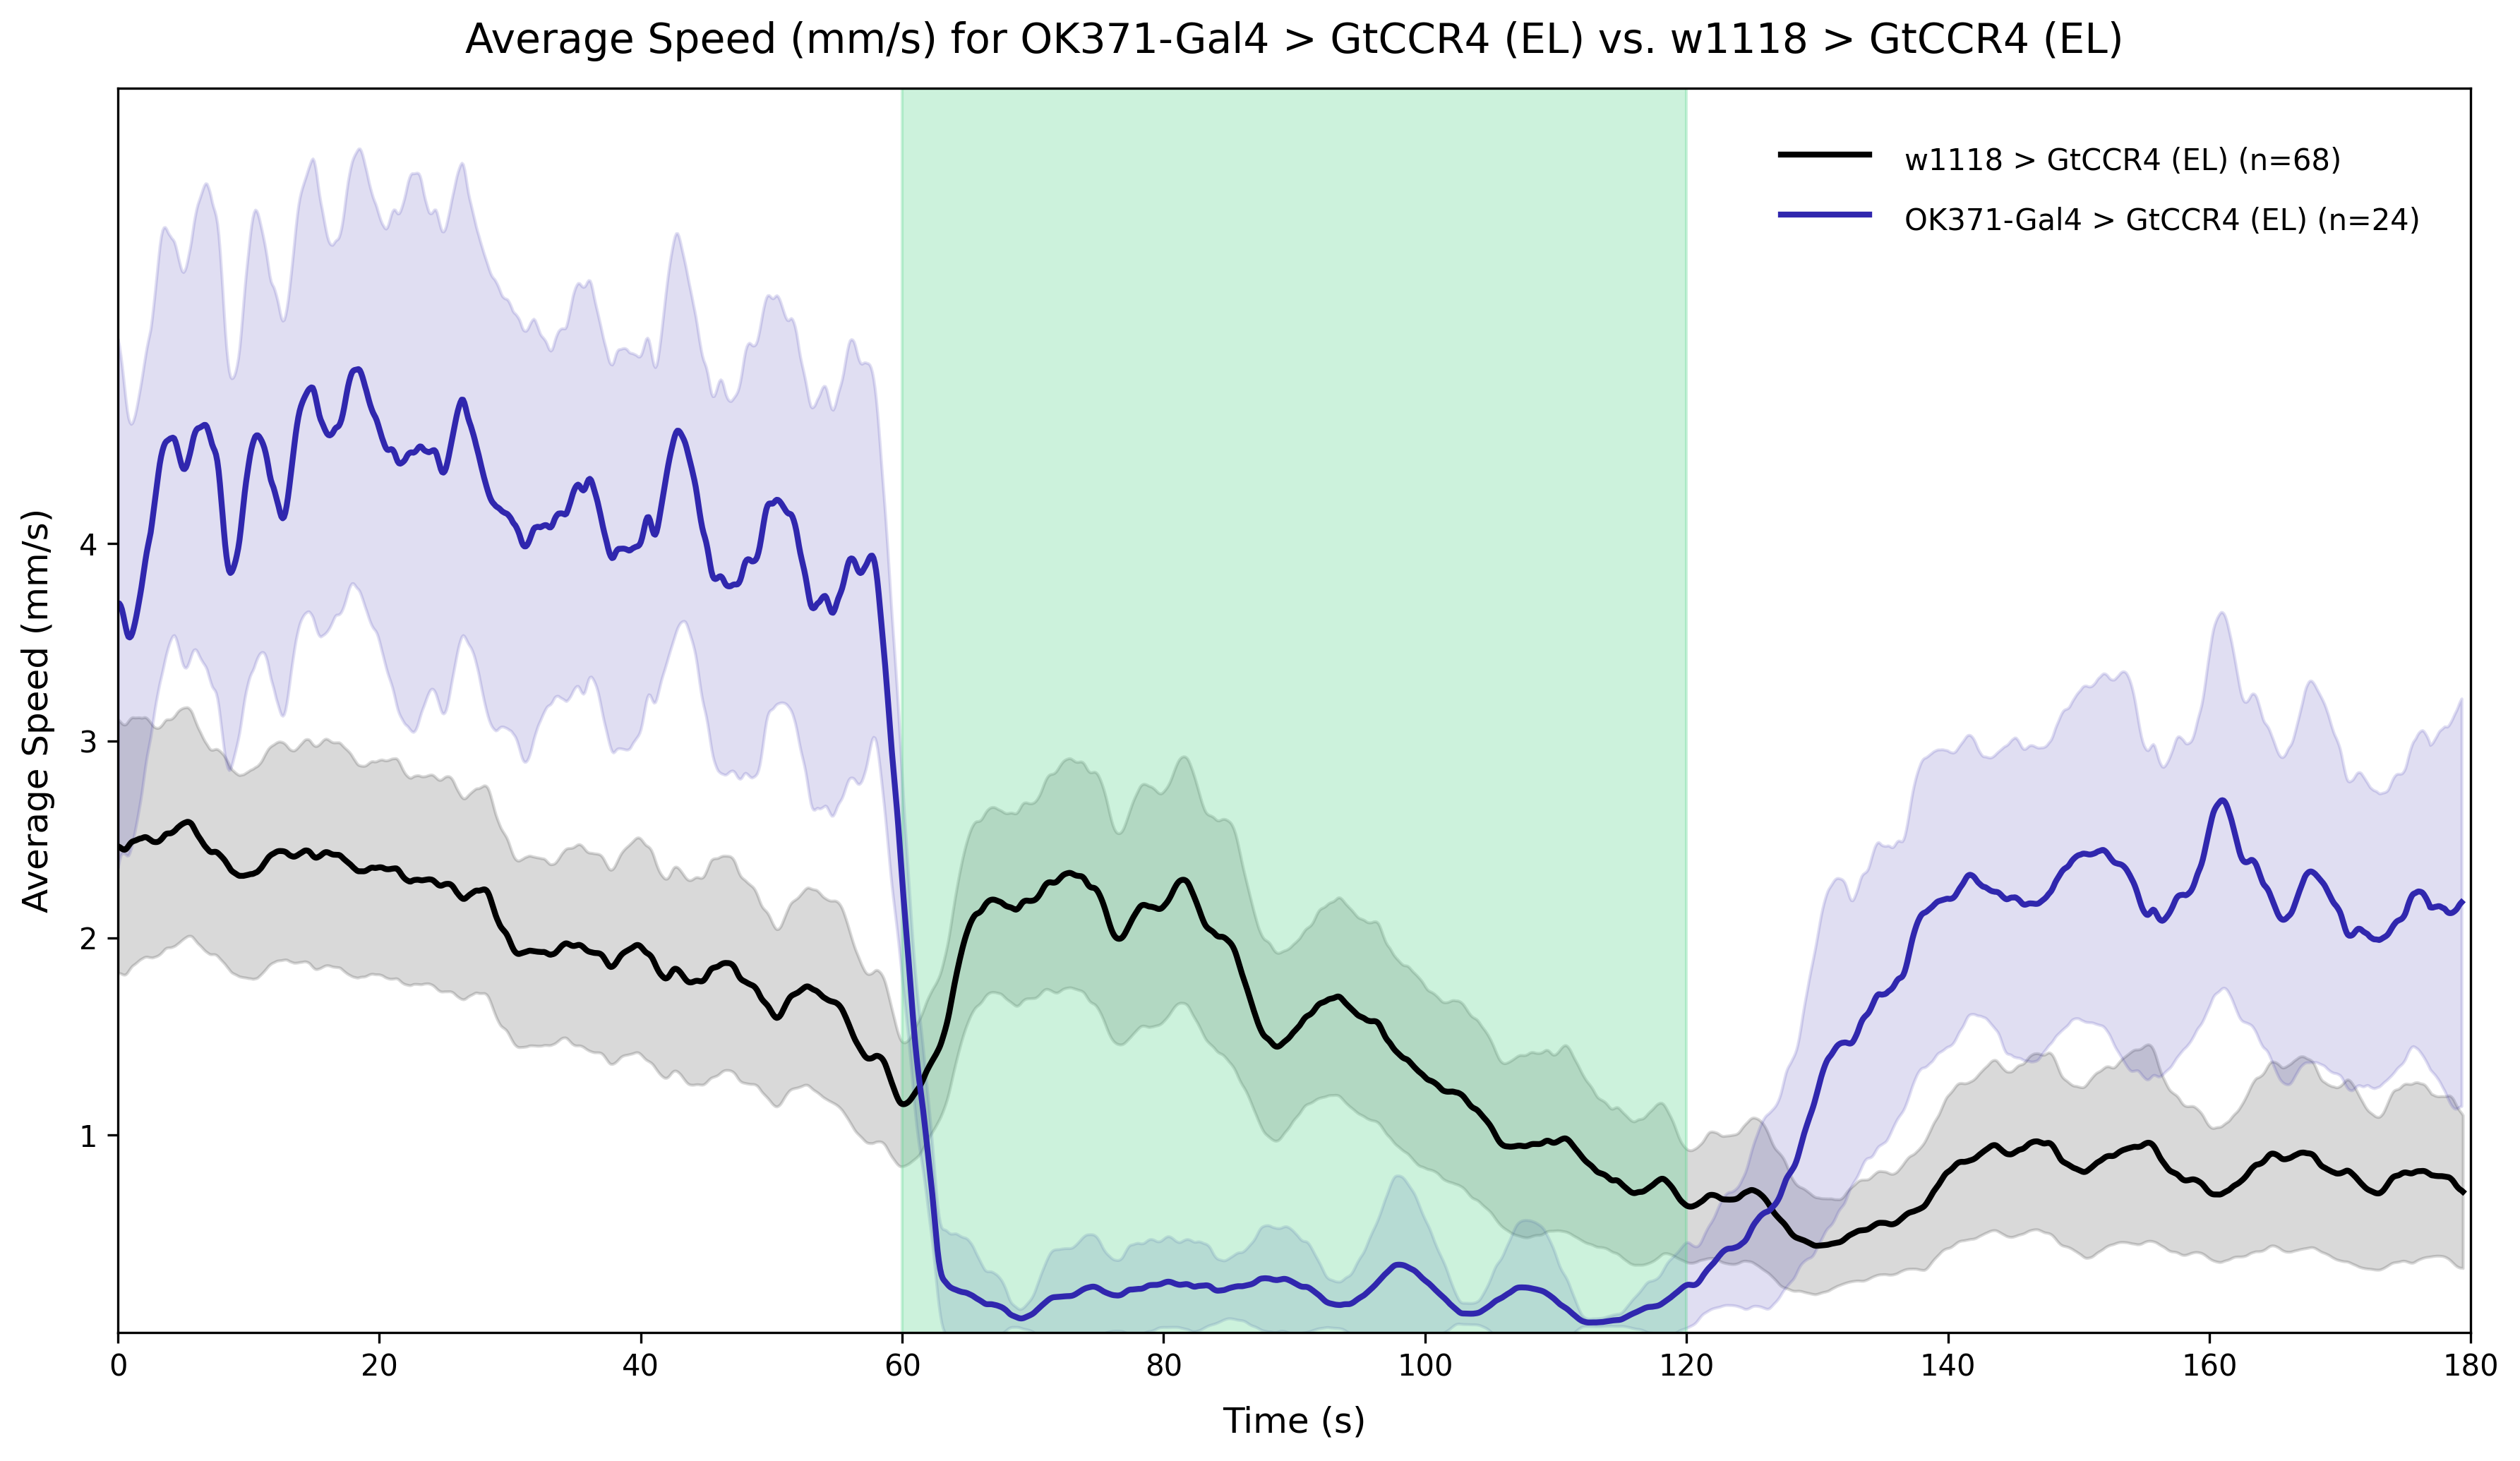

In [ ]:
# # Original linegraph code without automatic label/title generation


# # creates a line plot of average speed with 95% confidence intervals for two crosses
# # Timestamps are synchronized across flies, then normalized to start at 0s. 

# import pandas as pd
# import matplotlib.pyplot as plt
# import glob
# import os
# import numpy as np

# base_path = "C:\\Users\\Leif_D\\Documents\\trumelan data\\chrmine_gtccr4\\processed data"
# crosses = ["w1118 x GtCCR4 (EL)", "OK371 x GtCCR4 (EL)"]
# colors = {"w1118 x GtCCR4 (EL)": "#000000", "OK371 x GtCCR4 (EL)": "#3027AE"}

# labels = {
#     "w1118 x GtCCR4 (EL)": "w1118 > GtCCR4 (EL)",
#     "OK371 x GtCCR4 (EL)": "OK371-Gal4 > GtCCR4 (EL)"
# }

# plt.figure(figsize=(12, 7), dpi=300)

# framerate = 10  # Hz

# for cross_folder_name in crosses:
#     folder_path = os.path.join(base_path, cross_folder_name)
#     label = labels[cross_folder_name]

#     csv_files = glob.glob(os.path.join(folder_path, "*.csv"))
#     data_list = []

#     # Load each fly, convert Timestamp (ms) to Time (s) starting at 0, and store
#     for i, file in enumerate(csv_files, start=1):
#         df = pd.read_csv(file, usecols=["Timestamp (ms)", "Speed_Av_mm_per_sec"])
#         # Normalize timestamps to start at 0 s for each fly
#         df["Time (s)"] = (df["Timestamp (ms)"] - df["Timestamp (ms)"].iloc[0]) / 1000.0
#         df = df[["Time (s)", "Speed_Av_mm_per_sec"]]
#         df.rename(columns={"Speed_Av_mm_per_sec": f"{i}"}, inplace=True)
#         data_list.append(df)

#     # Skip if no data found for this cross
#     if not data_list:
#         continue

#     # Find overlapping time range across all flies for this cross
#     min_time = max(df["Time (s)"].min() for df in data_list)
#     max_time = min(df["Time (s)"].max() for df in data_list)

#     # Constrain to [0, 180] seconds, like your original script
#     min_time = max(min_time, 0)
#     max_time = min(max_time, 180)

#     if max_time <= min_time:
#         # No overlap in the desired range; skip this cross
#         continue

#     # Create a uniform time grid at the desired framerate
#     time_step = 1 / framerate
#     time_grid = np.arange(min_time, max_time, time_step)

#     # Interpolate each fly onto this uniform time grid
#     aligned_data = []
#     for df in data_list:
#         interp_series = pd.Series(
#             np.interp(time_grid, df["Time (s)"], df.iloc[:, 1]),
#             index=time_grid,
#             name=df.columns[1]
#         )
#         aligned_data.append(interp_series)

#     # Combine all interpolated series into one dataframe
#     all_data = pd.concat(aligned_data, axis=1)

#     # Smooth with rolling mean (5-second window, as in your original Movr Frame script)
#     window = framerate * 5  # 5 seconds
#     smoothed = all_data.rolling(window=window, min_periods=1, center=True).mean()

#     # Compute mean and 95% CI
#     mean_speed = smoothed.mean(axis=1)
#     std_speed = smoothed.std(axis=1)
#     n = smoothed.shape[1]
#     ci_upper = mean_speed + 1.96 * (std_speed / n**0.5)
#     ci_lower = mean_speed - 1.96 * (std_speed / n**0.5)

#     color = colors[cross_folder_name]
#     label_with_n = f"{label} (n={n})"
#     plt.plot(mean_speed.index, mean_speed.values, color=color, linewidth=2, label=label_with_n)
#     plt.fill_between(mean_speed.index, ci_lower, ci_upper, color=color, alpha=0.15)

# # Add illumination rectangle (60–120 s) after plotting so y-limits are known
# ylim = plt.ylim()
# illum_start, illum_duration = 60, 60
# plt.gca().add_patch(
#     plt.Rectangle(
#         (illum_start, ylim[0]),
#         illum_duration,
#         ylim[1] - ylim[0],
#         color="#58D68D",
#         alpha=0.3
#     )
# )

# plt.xlabel("Time (s)", fontsize=12, labelpad=8)
# plt.ylabel("Average Speed (mm/s)", fontsize=12, labelpad=8)
# plt.title("Average Speed (mm/s) for OK371-Gal4 > GtCCR4 (EL) vs. w1118 > GtCCR4 (EL)", fontsize=14, pad=12)
# plt.xlim(0, 180)
# plt.ylim(bottom=0)
# plt.yticks([1, 2, 3, 4])

# legend = plt.legend(frameon=False, fancybox=False, edgecolor='black',
#                     handlelength=3, handleheight=2, handletextpad=1.2, 
#                     borderpad=1.2, loc="upper right")
# legend.get_frame().set_linewidth(1)

# plt.tight_layout()

# output_path_img = 'C:\\Users\\Leif_D\\Documents\\trumelan data\\wtchr gtccr4 figures\\line graph svg\\20251111\\OK371-Gal4 x GtCCR4 (EL) line graph.svg'
# os.makedirs(os.path.dirname(output_path_img), exist_ok=True)

# # Export results
# plt.savefig(output_path_img)
# plt.show()


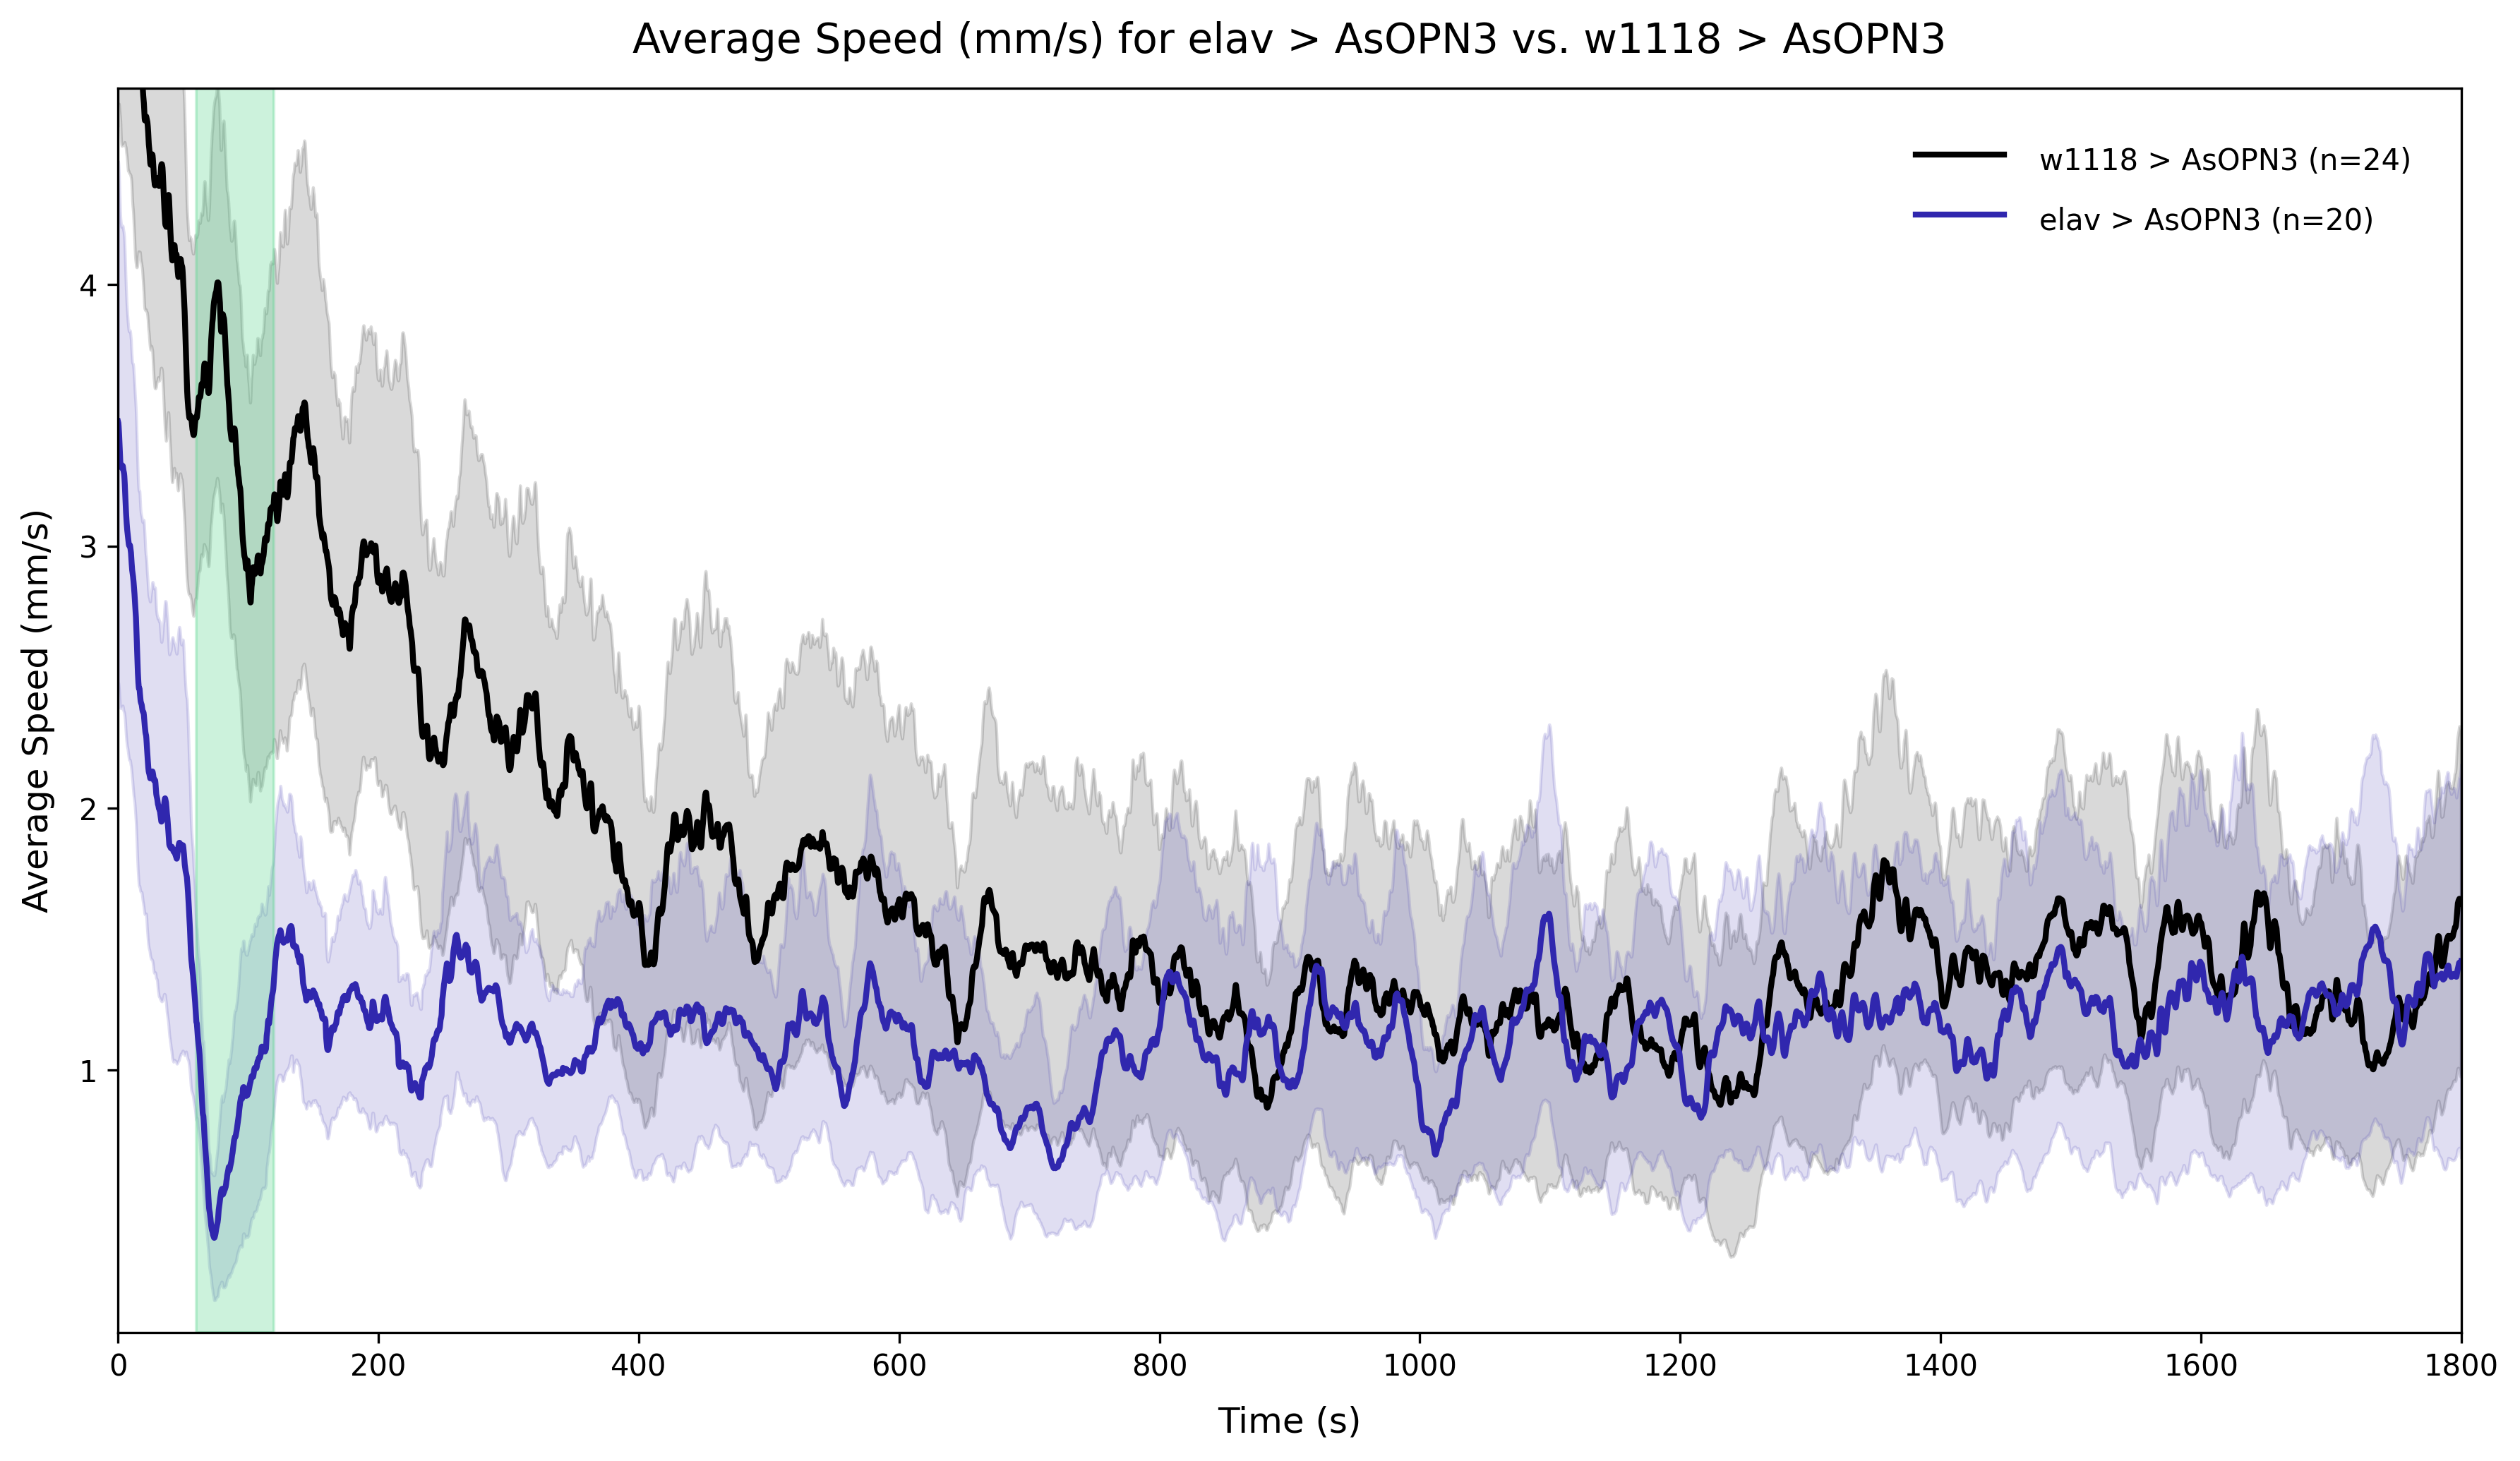

In [60]:
# creates a line plot of average speed with 95% confidence intervals for two crosses
# Timestamps are synchronized across flies, then normalized to start at 0s. DOESN'T use Movr Frame.

import pandas as pd
import matplotlib.pyplot as plt
import glob
import os
import numpy as np
import re

# -------------------------------------------------------------------
# USER INPUTS (edit these)
# -------------------------------------------------------------------
base_path = 'C:\\Users\\Leif_D\\Documents\\trumelan data\\eopn3'
crosses = ["w1118_eopn3_csv", "elav_eopn3_csv"]   # folder names
output_dir = 'C:\\Users\\Leif_D\\Documents\\trumelan data\\eopn3\\20251111 figures'
framerate = 10  # Hz
# -------------------------------------------------------------------

# Helper: map raw component names to display names.
def pretty_component(name: str) -> str:
    mapping = {
        "ok371": "OK371-Gal4",
        "wtchrmine": "WtChRmine",
        "cschrimson": "CsChrimson",
        "nanchung": "Nanchung-Gal4",
        "eopn3": "AsOPN3",
        "nsyb": "nSyb-Gal4",
        "cha": "ChAT-GFP",
        "acr": "GtACR1",
        "w1118": "w1118",
    }
    key = name.strip().lower()
    return mapping.get(key, name.strip())

# Parse messy folder names into clean component names
def parse_cross_components(cross_name: str):
    s = cross_name.strip()

    # If it explicitly uses "x", trust that
    if re.search(r'\bx\b', s, flags=re.IGNORECASE):
        parts = re.split(r'\bx\b', s, flags=re.IGNORECASE)
        parts = [p.strip() for p in parts if p.strip()]
    else:
        # Remove trailing “csv”, “5s”, etc.
        lower_s = s.lower()
        idx = lower_s.find('csv')
        if idx != -1:
            s = s[:idx]
        s = s.replace('_', ' ')
        raw_tokens = s.split()
        parts = []
        for t in raw_tokens:
            t_clean = t.strip()
            if re.match(r'^\d+s$', t_clean.lower()):
                continue
            if t_clean:
                parts.append(t_clean)
    return [pretty_component(p) for p in parts]

# Build labels automatically
labels = {}
for cross in crosses:
    components = parse_cross_components(cross)
    if len(components) >= 2:
        labels[cross] = f"{components[0]} > {components[1]}"
    else:
        labels[cross] = components[0]

# Auto-assign colors
default_colors = ["#000000", "#3027AE", "#AE2730", "#27AE60"]
colors = {cross: default_colors[i % len(default_colors)] for i, cross in enumerate(crosses)}

# Build chart title
if len(crosses) >= 2:
    title_str = f"Average Speed (mm/s) for {labels[crosses[1]]} vs. {labels[crosses[0]]}"
else:
    title_str = f"Average Speed (mm/s) for {labels[crosses[0]]}"

# -------------------------------------------------------------------
# PLOTTING
# -------------------------------------------------------------------
plt.figure(figsize=(12, 7), dpi=300)

for cross_folder_name in crosses:
    folder_path = os.path.join(base_path, cross_folder_name)
    label = labels[cross_folder_name]
    csv_files = glob.glob(os.path.join(folder_path, "*.csv"))
    data_list = []

    for i, file in enumerate(csv_files, start=1):
        df = pd.read_csv(file, usecols=["Timestamp (ms)", "Speed_Av_mm_per_sec"])
        df["Time (s)"] = (df["Timestamp (ms)"] - df["Timestamp (ms)"].iloc[0]) / 1000.0
        df = df[["Time (s)", "Speed_Av_mm_per_sec"]]
        df.rename(columns={"Speed_Av_mm_per_sec": f"{i}"}, inplace=True)
        data_list.append(df)

    if not data_list:
        continue

    min_time = max(df["Time (s)"].min() for df in data_list)
    max_time = min(df["Time (s)"].max() for df in data_list)
    min_time = max(min_time, 0)
    max_time = min(max_time, 1800)
    if max_time <= min_time:
        continue

    # Interpolate and align
    time_step = 1 / framerate
    time_grid = np.arange(min_time, max_time, time_step)
    aligned_data = [
        pd.Series(np.interp(time_grid, df["Time (s)"], df.iloc[:, 1]), index=time_grid)
        for df in data_list
    ]
    all_data = pd.concat(aligned_data, axis=1)

    # Smooth with rolling mean (5-second window)
    window = framerate * 20
    smoothed = all_data.rolling(window=window, min_periods=1, center=True).mean()

    # Compute mean and 95% CI
    mean_speed = smoothed.mean(axis=1)
    std_speed = smoothed.std(axis=1)
    n = smoothed.shape[1]
    ci_upper = mean_speed + 1.96 * (std_speed / n**0.5)
    ci_lower = mean_speed - 1.96 * (std_speed / n**0.5)

    color = colors[cross_folder_name]
    label_with_n = f"{label} (n={n})"
    plt.plot(mean_speed.index, mean_speed.values, color=color, linewidth=2, label=label_with_n)
    plt.fill_between(mean_speed.index, ci_lower, ci_upper, color=color, alpha=0.15)

# -------------------------------------------------------------------
# FIXED Y RANGE + FULL RECTANGLE
# -------------------------------------------------------------------
ymin, ymax = 0, 4.75
plt.ylim(ymin, ymax)

illum_start, illum_duration = 60, 60
ax = plt.gca()
ax.add_patch(
    plt.Rectangle(
        (illum_start, ymin),
        illum_duration,
        ymax - ymin,
        color="#58D68D",
        alpha=0.3
    )
)

# -------------------------------------------------------------------
# FINAL FORMATTING
# -------------------------------------------------------------------
plt.xlabel("Time (s)", fontsize=12, labelpad=8)
plt.ylabel("Average Speed (mm/s)", fontsize=12, labelpad=8)
plt.title(title_str, fontsize=14, pad=12)
plt.xlim(0, 1800)
plt.yticks([1, 2, 3, 4])

legend = plt.legend(frameon=False, fancybox=False, edgecolor='black',
                    handlelength=3, handleheight=2, handletextpad=1.2,
                    borderpad=1.2, loc="upper right")
legend.get_frame().set_linewidth(1)
plt.tight_layout()

# -------------------------------------------------------------------
# SAVE SVG
# -------------------------------------------------------------------
def svg_name_from_cross(cross_name: str) -> str:
    components = parse_cross_components(cross_name)
    if len(components) >= 2:
        return f"{components[0]} x {components[1]} line graph (30 min).svg"
    else:
        return f"{components[0]} line graph.svg"

main_cross = crosses[1] if len(crosses) >= 2 else crosses[0]
svg_name = svg_name_from_cross(main_cross)

os.makedirs(output_dir, exist_ok=True)
output_path_img = os.path.join(output_dir, svg_name)

plt.savefig(output_path_img)
plt.show()


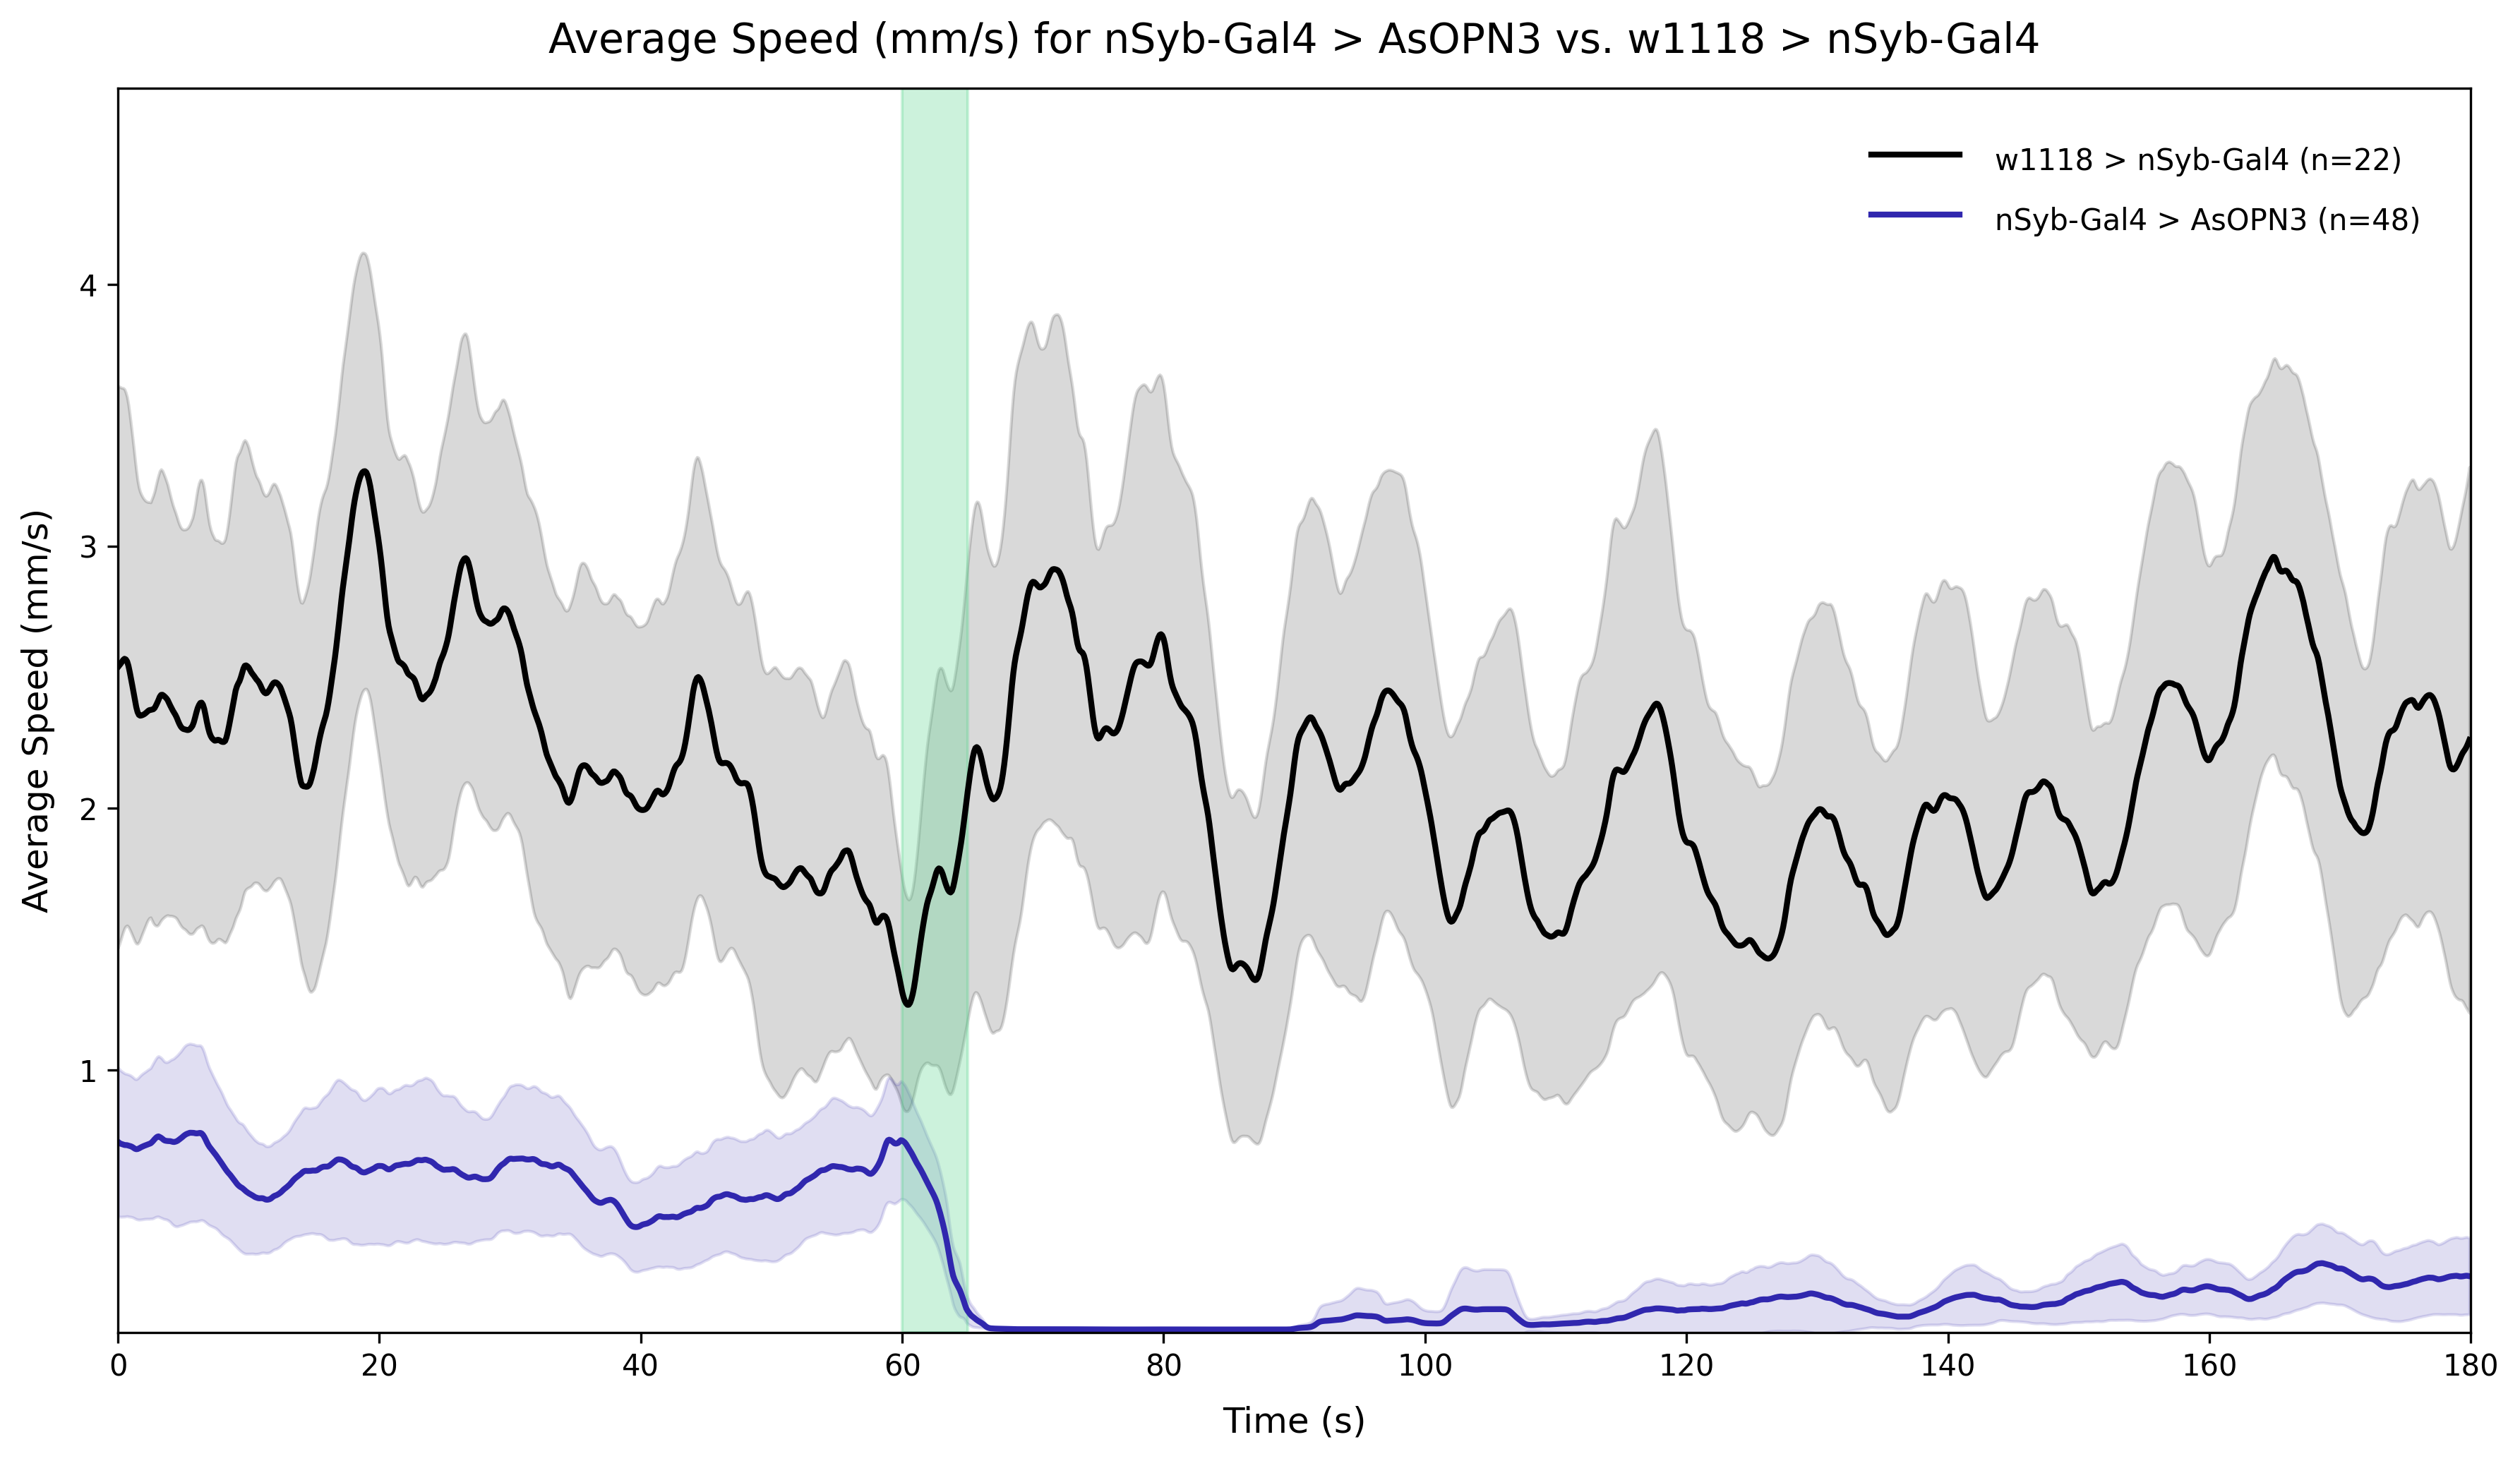

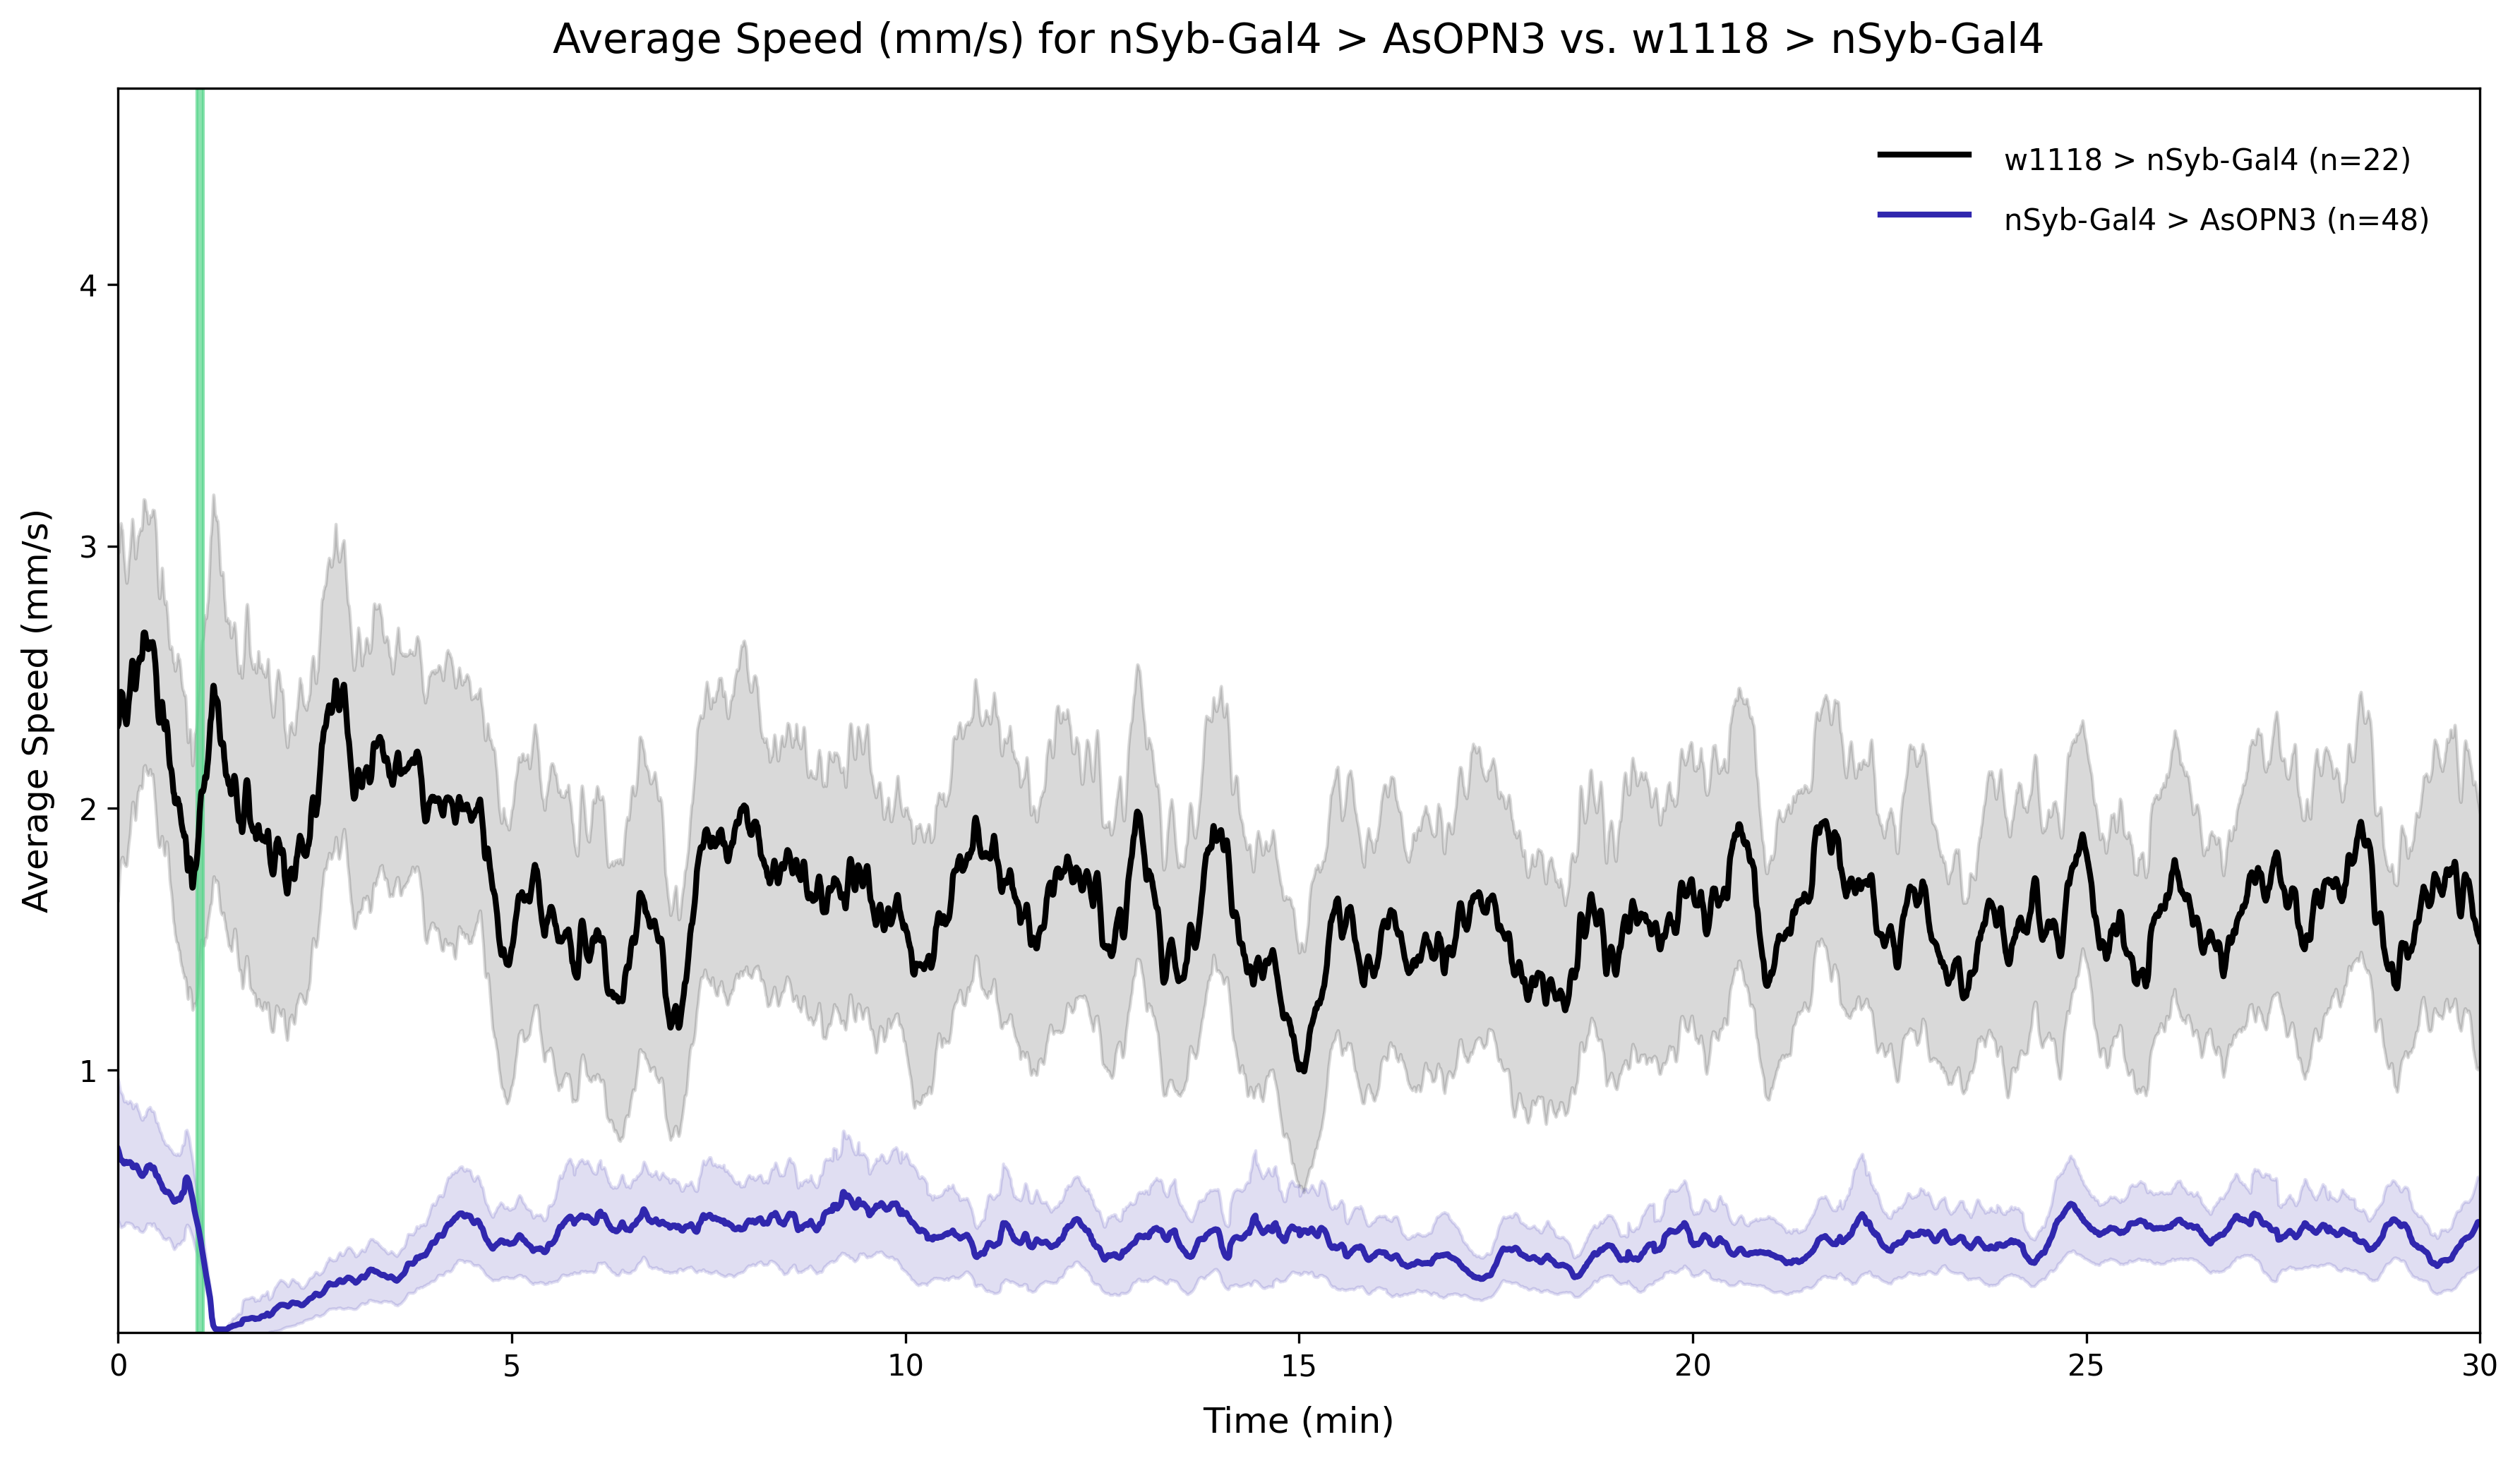

In [66]:
# creates two line plots of average speed with 95% confidence intervals for two crosses
# Timestamps are synchronized across flies, then normalized to start at 0s. DOESN'T use Movr Frame.

import pandas as pd
import matplotlib.pyplot as plt
import glob
import os
import numpy as np
import re

# -------------------------------------------------------------------
# USER INPUTS (edit these)
# -------------------------------------------------------------------
base_path = 'C:\\Users\\Leif_D\\Documents\\trumelan data\\eopn3'
crosses = ["w1118_nsyb_csv", "nsyb_eopn3_csv"]   # folder names
output_dir = 'C:\\Users\\Leif_D\\Documents\\trumelan data\\eopn3\\20251111 figures'
framerate = 10  # Hz
# -------------------------------------------------------------------

# Helper: map raw component names to display names.
def pretty_component(name: str) -> str:
    mapping = {
        "ok371": "OK371-Gal4",
        "wtchrmine": "WtChRmine",
        "cschrimson": "CsChrimson",
        "nanchung": "Nanchung-Gal4",
        "eopn3": "AsOPN3",
        "nsyb": "nSyb-Gal4",
        "cha": "ChAT-GFP",
        "acr": "GtACR1",
        "w1118": "w1118",
        "elav": "elav-Gal4",
    }
    key = name.strip().lower()
    return mapping.get(key, name.strip())

# Parse messy folder names into clean component names
def parse_cross_components(cross_name: str):
    s = cross_name.strip()

    # If it explicitly uses "x", trust that
    if re.search(r'\bx\b', s, flags=re.IGNORECASE):
        parts = re.split(r'\bx\b', s, flags=re.IGNORECASE)
        parts = [p.strip() for p in parts if p.strip()]
    else:
        # Remove trailing “csv”, “5s”, etc.
        lower_s = s.lower()
        idx = lower_s.find('csv')
        if idx != -1:
            s = s[:idx]
        s = s.replace('_', ' ')
        raw_tokens = s.split()
        parts = []
        for t in raw_tokens:
            t_clean = t.strip()
            # skip pure timing tokens like "5s"
            if re.match(r'^\d+s$', t_clean.lower()):
                continue
            if t_clean:
                parts.append(t_clean)
    return [pretty_component(p) for p in parts]

# Build labels automatically
labels = {}
for cross in crosses:
    components = parse_cross_components(cross)
    if len(components) >= 2:
        labels[cross] = f"{components[0]} > {components[1]}"
    else:
        labels[cross] = components[0]

# Auto-assign colors
default_colors = ["#000000", "#3027AE", "#AE2730", "#27AE60"]
colors = {cross: default_colors[i % len(default_colors)] for i, cross in enumerate(crosses)}

# Build chart title
if len(crosses) >= 2:
    title_str = f"Average Speed (mm/s) for {labels[crosses[1]]} vs. {labels[crosses[0]]}"
else:
    title_str = f"Average Speed (mm/s) for {labels[crosses[0]]}"

# -------------------------------------------------------------------
# SMALL-WINDOW PLOT (0–180 s, seconds axis, 5 s smoothing)
# -------------------------------------------------------------------
plt.figure(figsize=(12, 7), dpi=300)

for cross_folder_name in crosses:
    folder_path = os.path.join(base_path, cross_folder_name)
    label = labels[cross_folder_name]
    csv_files = glob.glob(os.path.join(folder_path, "*.csv"))
    data_list = []

    for i, file in enumerate(csv_files, start=1):
        df = pd.read_csv(file, usecols=["Timestamp (ms)", "Speed_Av_mm_per_sec"])
        df["Time (s)"] = (df["Timestamp (ms)"] - df["Timestamp (ms)"].iloc[0]) / 1000.0
        df = df[["Time (s)", "Speed_Av_mm_per_sec"]]
        df.rename(columns={"Speed_Av_mm_per_sec": f"{i}"}, inplace=True)
        data_list.append(df)

    if not data_list:
        continue

    # Limit analysis window to 0–180 s for this plot
    min_time = max(d["Time (s)"].min() for d in data_list)
    max_time = min(d["Time (s)"].max() for d in data_list)
    min_time = max(min_time, 0)
    max_time = min(max_time, 180)
    if max_time <= min_time:
        continue

    time_step = 1 / framerate
    time_grid = np.arange(min_time, max_time, time_step)
    aligned_data = [
        pd.Series(np.interp(time_grid, d["Time (s)"], d.iloc[:, 1]), index=time_grid)
        for d in data_list
    ]
    all_data = pd.concat(aligned_data, axis=1)

    # Smooth with rolling mean (5-second window)
    window = framerate * 5
    smoothed = all_data.rolling(window=window, min_periods=1, center=True).mean()

    # Compute mean and 95% CI
    mean_speed = smoothed.mean(axis=1)
    std_speed = smoothed.std(axis=1)
    n = smoothed.shape[1]
    ci_upper = mean_speed + 1.96 * (std_speed / n**0.5)
    ci_lower = mean_speed - 1.96 * (std_speed / n**0.5)

    color = colors[cross_folder_name]
    label_with_n = f"{label} (n={n})"
    plt.plot(mean_speed.index, mean_speed.values, color=color, linewidth=2, label=label_with_n)
    plt.fill_between(mean_speed.index, ci_lower, ci_upper, color=color, alpha=0.15)

# Fixed Y range + illumination rectangle
ymin, ymax = 0, 4.75
plt.ylim(ymin, ymax)

illum_start, illum_duration = 60, 5
ax = plt.gca()
ax.add_patch(
    plt.Rectangle(
        (illum_start, ymin),
        illum_duration,
        ymax - ymin,
        color="#58D68D",
        alpha=0.3
    )
)

# Formatting (seconds axis)
plt.xlabel("Time (s)", fontsize=12, labelpad=8)
plt.ylabel("Average Speed (mm/s)", fontsize=12, labelpad=8)
plt.title(title_str, fontsize=14, pad=12)
plt.xlim(0, 180)
plt.yticks([1, 2, 3, 4])

legend = plt.legend(frameon=False, fancybox=False, edgecolor='black',
                    handlelength=3, handleheight=2, handletextpad=1.2,
                    borderpad=1.2, loc="upper right")
legend.get_frame().set_linewidth(1)
plt.tight_layout()

# Save SVG for short plot
def svg_name_short(cross_name: str) -> str:
    components = parse_cross_components(cross_name)
    if len(components) >= 2:
        return f"{components[0]} x {components[1]} line graph.svg"
    else:
        return f"{components[0]} line graph.svg"

main_cross = crosses[1] if len(crosses) >= 2 else crosses[0]
svg_name = svg_name_short(main_cross)

os.makedirs(output_dir, exist_ok=True)
output_path_img = os.path.join(output_dir, svg_name)

plt.savefig(output_path_img)
plt.show()

# -------------------------------------------------------------------
# LONG-WINDOW PLOT (0–1800 s, minutes axis, 20 s smoothing)
# -------------------------------------------------------------------
plt.figure(figsize=(12, 7), dpi=300)

for cross_folder_name in crosses:
    folder_path = os.path.join(base_path, cross_folder_name)
    label = labels[cross_folder_name]
    csv_files = glob.glob(os.path.join(folder_path, "*.csv"))
    data_list = []

    for i, file in enumerate(csv_files, start=1):
        df = pd.read_csv(file, usecols=["Timestamp (ms)", "Speed_Av_mm_per_sec"])
        df["Time (s)"] = (df["Timestamp (ms)"] - df["Timestamp (ms)"].iloc[0]) / 1000.0
        df = df[["Time (s)", "Speed_Av_mm_per_sec"]]
        df.rename(columns={"Speed_Av_mm_per_sec": f"{i}"}, inplace=True)
        data_list.append(df)

    if not data_list:
        continue

    # Limit analysis window to 0–1800 s for this plot
    min_time = max(d["Time (s)"].min() for d in data_list)
    max_time = min(d["Time (s)"].max() for d in data_list)
    min_time = max(min_time, 0)
    max_time = min(max_time, 1800)
    if max_time <= min_time:
        continue

    time_step = 1 / framerate
    time_grid = np.arange(min_time, max_time, time_step)
    aligned_data = [
        pd.Series(np.interp(time_grid, d["Time (s)"], d.iloc[:, 1]), index=time_grid)
        for d in data_list
    ]
    all_data = pd.concat(aligned_data, axis=1)

    # Smooth with rolling mean (20-second window)
    window = framerate * 20
    smoothed = all_data.rolling(window=window, min_periods=1, center=True).mean()

    # Compute mean and 95% CI
    mean_speed = smoothed.mean(axis=1)
    std_speed = smoothed.std(axis=1)
    n = smoothed.shape[1]
    ci_upper = mean_speed + 1.96 * (std_speed / n**0.5)
    ci_lower = mean_speed - 1.96 * (std_speed / n**0.5)

    color = colors[cross_folder_name]
    label_with_n = f"{label} (n={n})"
    plt.plot(mean_speed.index, mean_speed.values, color=color, linewidth=2, label=label_with_n)
    plt.fill_between(mean_speed.index, ci_lower, ci_upper, color=color, alpha=0.15)

# Fixed Y range + illumination rectangle
ymin, ymax = 0, 4.75
plt.ylim(ymin, ymax)

illum_start, illum_duration = 60, 5   # still in seconds
ax = plt.gca()
ax.add_patch(
    plt.Rectangle(
        (illum_start, ymin),
        illum_duration,
        ymax - ymin,
        color="#58D68C",
        alpha=0.7
    )
)

# Formatting (minutes axis)
plt.ylabel("Average Speed (mm/s)", fontsize=12, labelpad=8)
plt.title(title_str, fontsize=14, pad=12)

# x-axis: 0–1800 s, shown as minutes
plt.xlim(0, 1800)
tick_positions = np.arange(0, 1801, 300)  # every 5 min (300 s)
tick_labels = [str(int(tp / 60)) for tp in tick_positions]  # 0, 5, 10, ..., 30
plt.xticks(tick_positions, tick_labels)
plt.xlabel("Time (min)", fontsize=12, labelpad=8)

plt.yticks([1, 2, 3, 4])

legend = plt.legend(frameon=False, fancybox=False, edgecolor='black',
                    handlelength=3, handleheight=2, handletextpad=1.2,
                    borderpad=1.2, loc="upper right")
legend.get_frame().set_linewidth(1)
plt.tight_layout()

# Save SVG for long plot
def svg_name_long(cross_name: str) -> str:
    components = parse_cross_components(cross_name)
    if len(components) >= 2:
        return f"{components[0]} x {components[1]} line graph (30 min).svg"
    else:
        return f"{components[0]} line graph (30 min).svg"

svg_name_longplot = svg_name_long(main_cross)
output_path_img_long = os.path.join(output_dir, svg_name_longplot)

plt.savefig(output_path_img_long)
plt.show()


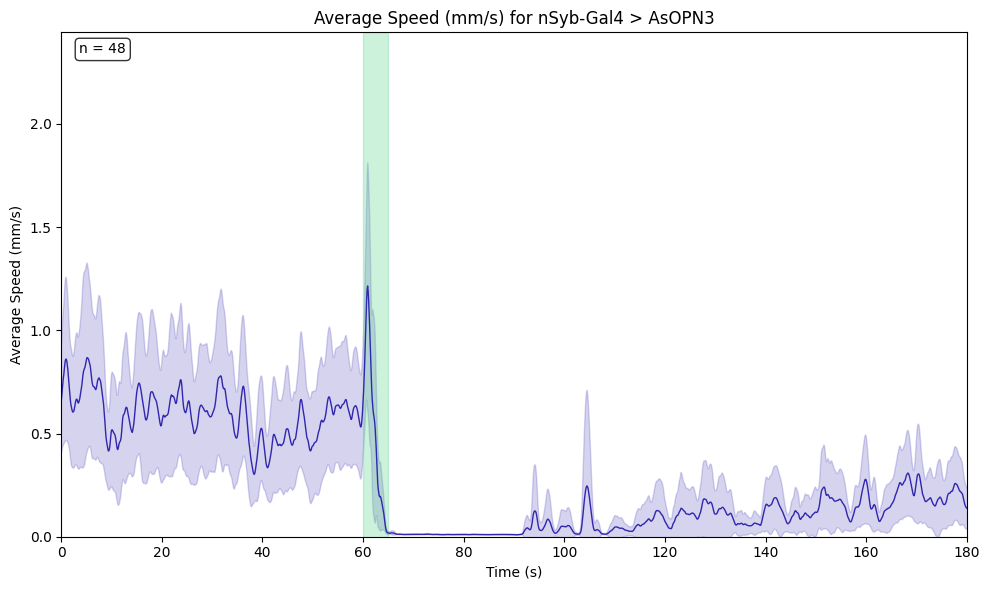

In [34]:
#single-line graph

import pandas as pd
import matplotlib.pyplot as plt
import glob
import os
import numpy as np
import re

# -------------------------------------------------------------------
# USER INPUTS (edit these)
# -------------------------------------------------------------------
cross_folder_name = "nsyb_eopn3_csv"
base_path = "C:\\Users\\Leif_D\\Documents\\trumelan data\\eopn3"
folder_path = os.path.join(base_path, cross_folder_name)
# -------------------------------------------------------------------

# -------------------------------------------------------------------
# INPUT pretty names ("elav" : "Elav-Gal4", etc.). After this, you shouldn't need to touch anything :)
# -------------------------------------------------------------------
def pretty_component(name: str) -> str:
    mapping = {
        "ok371": "OK371-Gal4",
        "wtchrmine": "WtChRmine",
        "cschrimson": "CsChrimson",
        "nanchung": "Nanchung-Gal4",
        "eopn3": "AsOPN3",
        "nsyb": "nSyb-Gal4",
        "cha": "ChAT-GFP",
        "acr": "GtACR1",
        "w1118": "w1118",
        "elav": "Elav-Gal4",
    }
    key = name.strip().lower()
    return mapping.get(key, name.strip())

# Parse messy folder names into clean component names
def parse_cross_components(cross_name: str):
    s = cross_name.strip()

    # If it explicitly uses "x", trust that
    if re.search(r'\bx\b', s, flags=re.IGNORECASE):
        parts = re.split(r'\bx\b', s, flags=re.IGNORECASE)
        parts = [p.strip() for p in parts if p.strip()]
    else:
        # Remove trailing “csv”, “5s”, etc.
        lower_s = s.lower()
        idx = lower_s.find('csv')
        if idx != -1:
            s = s[:idx]
        s = s.replace('_', ' ')
        raw_tokens = s.split()
        parts = []
        for t in raw_tokens:
            t_clean = t.strip()
            # skip pure timing tokens like "5s"
            if re.match(r'^\d+s$', t_clean.lower()):
                continue
            if t_clean:
                parts.append(t_clean)
    return [pretty_component(p) for p in parts]

labels = {}
# Parse components from the folder name 
components = parse_cross_components(cross_folder_name)

# Build a safe title string depending on how many components were found
if len(components) >= 2:
    title_name = f"Average Speed (mm/s) for {components[0]} > {components[1]}"
else:
    # Fallback if parsing returned only one component
    title_name = f"Average Speed (mm/s) for {components[0]}"

# Load and process data
csv_files = glob.glob(os.path.join(folder_path, "*.csv"))
data_list = []

for i, file in enumerate(csv_files, start=1):
    df = pd.read_csv(file, usecols=["Timestamp (ms)", "Speed_Av_mm_per_sec"])
    df["Time (s)"] = (df["Timestamp (ms)"] - df["Timestamp (ms)"].iloc[0]) / 1000
    df = df[["Time (s)", "Speed_Av_mm_per_sec"]]
    df.rename(columns={"Speed_Av_mm_per_sec": f"{i}"}, inplace=True)
    data_list.append(df)

# Find global time range across all flies
min_time = max(df["Time (s)"].min() for df in data_list)
max_time = min(df["Time (s)"].max() for df in data_list)

# Create a uniform time grid (1 / framerate step)
framerate = 10
time_grid = np.arange(min_time, max_time, 1/framerate)

# Resample each fly's data to this uniform grid for synchronization
aligned_data = []
for df in data_list:
    interp_df = pd.Series(
        np.interp(time_grid, df["Time (s)"], df.iloc[:, 1]),  # interpolate on uniform time grid
        index=time_grid
    )
    aligned_data.append(interp_df)

# Combine all interpolated series into one dataframe
all_data = pd.concat(aligned_data, axis=1)
#all_data.to_csv('all_data.csv')  # Save combined data to CSV for verification if needed
# Smooth with rolling mean (window = 1s)
window = framerate
smoothed = all_data.rolling(window=window, min_periods=1, center=True).mean()

# Compute mean and 95% CI
mean_speed = smoothed.mean(axis=1)
std_speed = smoothed.std(axis=1)
n = smoothed.shape[1]
ci_upper = mean_speed + 1.96 * (std_speed / n**0.5)
ci_lower = mean_speed - 1.96 * (std_speed / n**0.5)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(mean_speed.index, mean_speed.values, color="#3027AE", linewidth=1)
plt.fill_between(mean_speed.index, ci_lower, ci_upper, color="#3027AE", alpha=0.2)

# Add illumination rectangle (60–120s)
ylim = plt.ylim()
illum_start, illum_duration = 60, 5
plt.gca().add_patch(
    plt.Rectangle(
        (illum_start, ylim[0]),
        illum_duration,
        ylim[1] - ylim[0],
        color='#58D68D',
        alpha=0.3
    )
)

# Add sample count annotation
plt.text(0.02, 0.98, f'n = {n}', 
         transform=plt.gca().transAxes,
         fontsize=10,
         verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.xlabel("Time (s)")
plt.ylabel("Average Speed (mm/s)")
plt.title(title_name)
plt.ylim(bottom=0)
plt.xlim(0, 180)
plt.tight_layout()

output_dir = "C:\\Users\\Leif_D\\Documents\\trumelan data\\eopn3\\20251114 figure"
os.makedirs(output_dir, exist_ok=True)
plt.savefig(os.path.join(output_dir, f"{components[0]} x {components[1]} single-line graph.svg"), format='svg', dpi=300, bbox_inches='tight')

plt.show()